<a href="https://colab.research.google.com/github/aninditabasak98/BIAIAssignment1AninditaBasak123-/blob/main/BI_AI_2026_Assignment_3_Basak_Anindita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain-Inspired AI (CPE 4953.001, EE 5263.003) — Assignment 3: Synaptic Plasticity and Rate-Based Neural Networks
### Student Template Notebook

- **Name:** _<Basak, Anindita>_  
- **UTSA ID:** _<kds250>_  

## Instructions
- Complete all **TODO** blocks.
- Use clear comments and label plots (titles, axes, legends).
- Keep your code **readable** and **reproducible** (set seeds when asked).

## Points
Total points: For undergraduate students; 80 points
For graduate students: 100 points

## Evaluation Criteria
The test cells with assertion checks must pass to earn points. If the test cells pass the assertion checks but the codes have mistakes (e.g., two wrongs making the result right), points may not be awarded. In case of visualization tasks, the generated plots must closely/reasonably match the provided expected plots. Please ensure you address all the questions given in the Assignment PDF, follow the instructions carefully.

## Due Date
Midnight (11:59 pm) of March 17, 2026.


# Setup
Import libraries and define any shared helper functions here.


In [73]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets


# Part 1: Synaptic Plasticity

## Question 1 (20 pts) — STDP

Two plasticity rules:

**Basic STDP model (Eq. 1)**  
\[
\Delta W =
\begin{cases}
A_+\exp\left(-\frac{\Delta t}{\tau_+}\right), & \Delta t>0\\
-A_-\exp\left(\frac{\Delta t}{\tau_-}\right), & \Delta t\le 0
\end{cases}
\]
where \(\Delta t = t_{post} - t_{pre}\).

**Synaptic trace rule (Eqs. 2–3)**  
\[
\Delta W = A\,(X_{pre} - X_{tar})
\]
\[
X_{pre}(t+\Delta T) =
\begin{cases}
1, & \text{if a pre-synaptic spike occurs at time } t\\
k\,X_{pre}(t), & \text{otherwise}
\end{cases}
\]

Use **A = A\_+ = A\_- = 0.1** for all sweeps/simulations in this question.  
Assume all times in seconds.


### 1(a) [9 pts]
Plot $\Delta W$ as a function of $\Delta t$ for the basic STDP rule (Eq. 1). Use seconds for all time quantities. Sweep $\Delta t$ from −0.010 s to 0.010 s in steps of 0.0001 s, and plot three curves for $\tau \in {0.002,\text{s},,0.005,\text{s},,0.010,\text{s}}$ (i.e., 2 ms, 5 ms, 10 ms).


Expected plot:
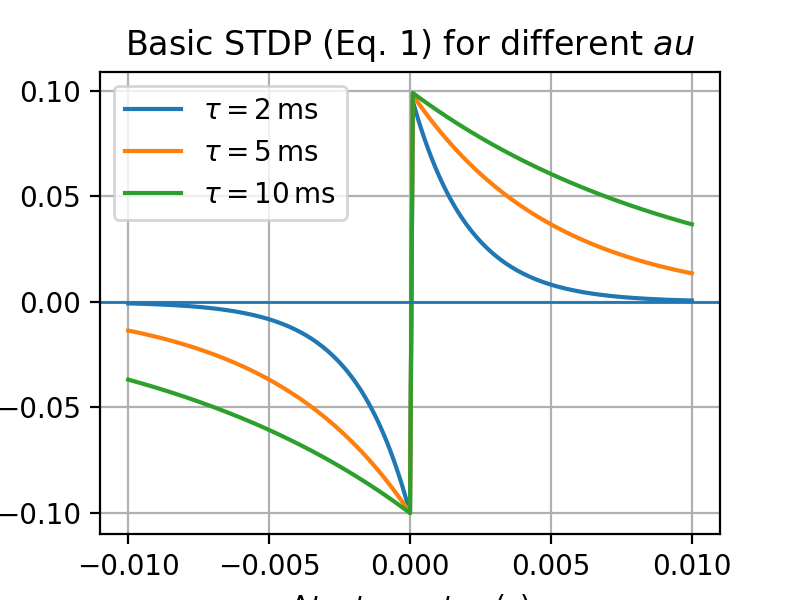

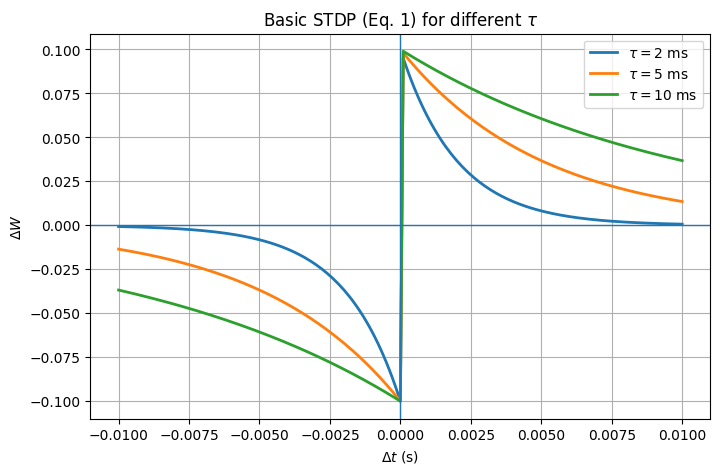

In [74]:
# =========================
# (a) Basic STDP (Eq. 1) — try multiple τ values
# =========================

# Given
A_plus = 0.1
A_minus = 0.1

# IMPORTANT: Use seconds everywhere in this question

# TODO: Use these τ values (convert from ms to seconds)
tau_list_s = [2e-3, 5e-3, 10e-3]  # 2 ms, 5 ms, 10 ms

# Sweep Δt from -10 ms to 10 ms in steps of 0.1 ms (all converted to seconds)
dt_min_s = -10e-3
dt_max_s =  10e-3
dt_step_s = 0.1e-3  # 0.1 ms = 1e-4 s

n_points = int(np.round((dt_max_s - dt_min_s) / dt_step_s)) + 1
delta_t = np.linspace(dt_min_s, dt_max_s, n_points)

# TODO: For each τ in tau_list_s:
#   1) set tau_plus = tau_minus = τ
delta_w_curves = []

for tau in tau_list_s:
    tau_plus = tau
    tau_minus = tau
#   2) compute ΔW for every Δt using Eq. (1)
    delta_w = np.zeros_like(delta_t)

    # Eq. (1)
    # ΔW = A+ * exp(-Δt/tau+)     if Δt > 0
    # ΔW = -A- * exp( Δt/tau-)    if Δt <= 0

    for i, dt in enumerate(delta_t):
        if dt > 0:
            delta_w[i] = A_plus * np.exp(-dt / tau_plus)
        else:
            delta_w[i] = -A_minus * np.exp(dt / tau_minus)


#   3) store results so you can plot three curves (one per τ)

    delta_w_curves.append(delta_w)

# TODO: plot ΔW in y axis with Δt in x-axis for the give tau values
plt.figure(figsize=(8, 5))

labels = [r'$\tau = 2$ ms', r'$\tau = 5$ ms', r'$\tau = 10$ ms']

for i, delta_w in enumerate(delta_w_curves):
    plt.plot(delta_t, delta_w, linewidth=2, label=labels[i])

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'$\Delta W$')
plt.title(r'Basic STDP (Eq. 1) for different $\tau$')
plt.legend()
plt.grid(True)
plt.show()

### 1(b) [9 pts]
Plot $\Delta W$ for the **synaptic trace rule** (Eqs. 2–3) as a function of the delay between pre- and post-synaptic spikes.

- The **weight update is applied when the post-synaptic spike occurs**.
- Use **simulation timestep** $\Delta T = 1$ ms
- Set **trace decay rate** $k = 0.9$
- For each delay $d \in \{1,2,\dots,20\}$ ms:
  - Set a single pre-synaptic spike at $t=0$ so that $X_{pre}(0)=1$
  - Assume no other pre-spikes occur. For the next $d$ ms update: $X_{pre}(t+\Delta T)=kX_{pre}(t)$
  - At $t=d$ ms compute: $\Delta W = A\,(X_{pre}(d) - X_{tar})$
- Repeat for **three** target values: $X_{tar} \in \{0.1, 0.5, 0.9\}$


Expected plot:
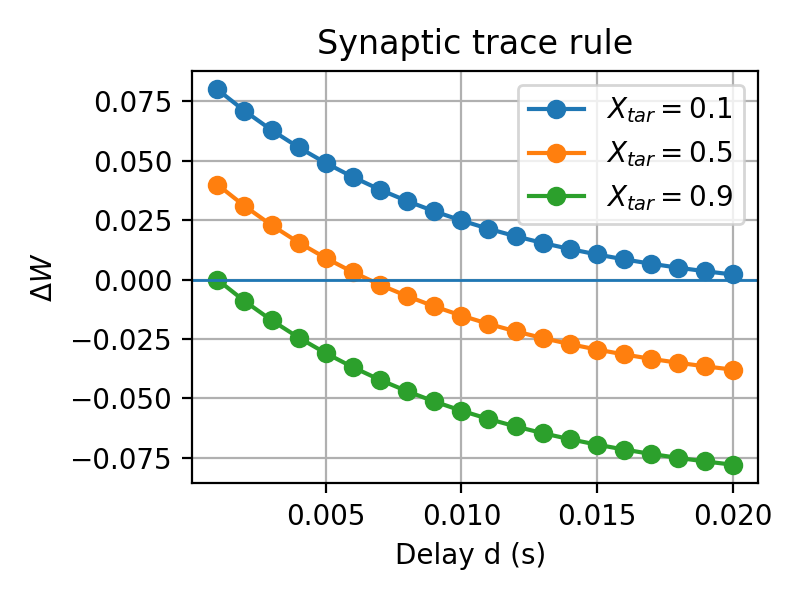

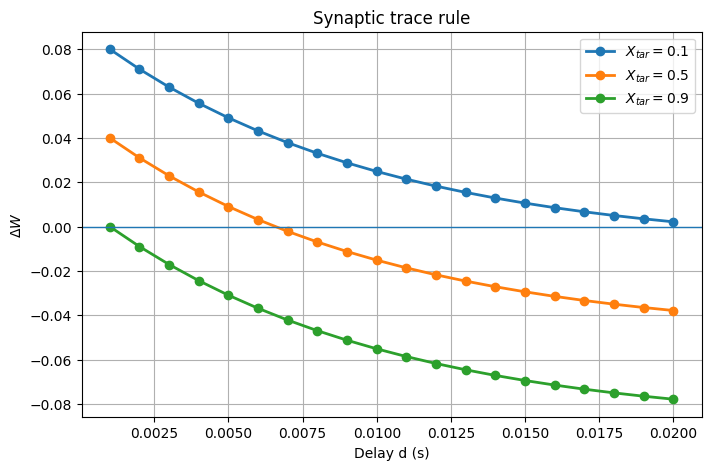

In [75]:
# =========================
# (b) Synaptic Trace Rule (Eqs. 2-3)
# =========================

# Given
A = 0.1
k = 0.9

# IMPORTANT: Use seconds everywhere
DeltaT = 1e-3  # 1 ms in seconds
Xtar_list = [0.1, 0.5, 0.9]

# Delay sweep from 1 ms to 20 ms (in seconds), step = 1 ms
d_min_s  = 1e-3   # 1 ms  -> seconds
d_max_s  = 20e-3  # 20 ms -> seconds
d_step_s = 1e-3   # 1 ms  -> seconds

# Build delay axis with guaranteed endpoints (includes both 1 ms and 20 ms)
n_points = int(np.round((d_max_s - d_min_s) / d_step_s)) + 1
delays = np.linspace(d_min_s, d_max_s, n_points)  # seconds

# TODO: For each Xtar in Xtar_list:
#   1) For each delay d in delays:
#       - Set pre-syn spike at t=0 so Xpre(0)=1
#       - No other pre spikes; decay Xpre for duration d using timestep DeltaT
#       - At t=d (post spike), compute ΔW = A * (Xpre - Xtar)
#   2) Store ΔW vs delay for plotting (one curve per Xtar)
#
# TODO: Make a plot of ΔW vs delay (in seconds), with a legend for Xtar.

# Your code here
delta_w_curves = []
for Xtar in Xtar_list:
    delta_w_vs_delay = []

    for d in delays:
        # Pre-synaptic spike at t = 0
        Xpre = 1.0

        n_decay_steps = int(np.round(d / DeltaT))

        for _ in range(n_decay_steps):
            Xpre = k * Xpre

        delta_w = A * (Xpre - Xtar)
        delta_w_vs_delay.append(delta_w)
    delta_w_curves.append(np.array(delta_w_vs_delay))

plt.figure(figsize=(8, 5))

for i, Xtar in enumerate(Xtar_list):
    plt.plot(delays, delta_w_curves[i], marker='o', linewidth=2,
             label=fr'$X_{{tar}} = {Xtar}$')

plt.axhline(0, linewidth=1)
plt.xlabel('Delay d (s)')
plt.ylabel(r'$\Delta W$')
plt.title('Synaptic trace rule')
plt.legend()
plt.grid(True)
plt.show()




### 1(c) [1 pt]
True/False: Increasing $\tau_+$ and $\tau_-$ in Eq. (1) makes STDP effective over a longer time span (i.e., $\Delta W$ decays more slowly as $|\Delta t|$ increases).

**Answer:** True. As tau increases Delta w decays more slowly.


### 1(d) [1 pt]
True/False: In the synaptic trace rule, for sufficiently large delays $d$ between pre-synaptic and post-synaptic spikes, the weight update becomes negative ($\Delta W < 0$).

**Answer:** True

---


# Part 2: Rate-Based Neural Networks (Fisher Iris)

The Fisher Iris dataset has 150 samples from 3 classes. Each sample has 4 features.
You will implement and compare:
- Logistic Regression (Question 2)
- Extreme Learning Machine (Question 3)
- Multi-Layer Perceptron (Question 4)

In all cases:
- Use a **50/50** train/test split (shuffle each run).
- Run **at least 5 trials** (different random seeds).
- Plot **mean train/test accuracy vs epoch**


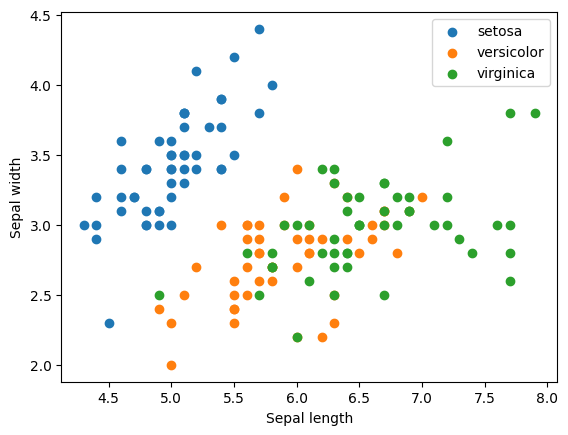

In [76]:
# -------------------------
# Reproducibility + runs
# -------------------------
n_runs = 5
base_seed = 0

# Hyperparameters
lr = 1e-1       # Learning rate
bias = 1        # Bias term (1)
n_epochs = 100  # Number of epochs

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# -------------------------
# Load data
# -------------------------
iris = datasets.load_iris()
samples = iris.data
target = iris.target
names = iris.target_names

# Plot data (first 2 features)
plot_data = samples[:, :2]
x_min, x_max = plot_data[:, 0].min() - .5, plot_data[:, 0].max() + .5
y_min, y_max = plot_data[:, 1].min() - .5, plot_data[:, 1].max() + .5

fig, ax = plt.subplots()
scatter_x = plot_data[:, 0]
scatter_y = plot_data[:, 1]
for g in np.unique(target):
    i = np.where(target == g)
    ax.scatter(scatter_x[i], scatter_y[i], label=g)
ax.legend(names)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

# Dataset sizes (we will reshuffle per run)
n_samples = samples.shape[0]
n_classes = len(np.unique(target))


# Question 2: Logistic Regression (10 pts)
Implement LR using Eq. (4) and run 5 trials. Fill TODOs.

Expected plot:

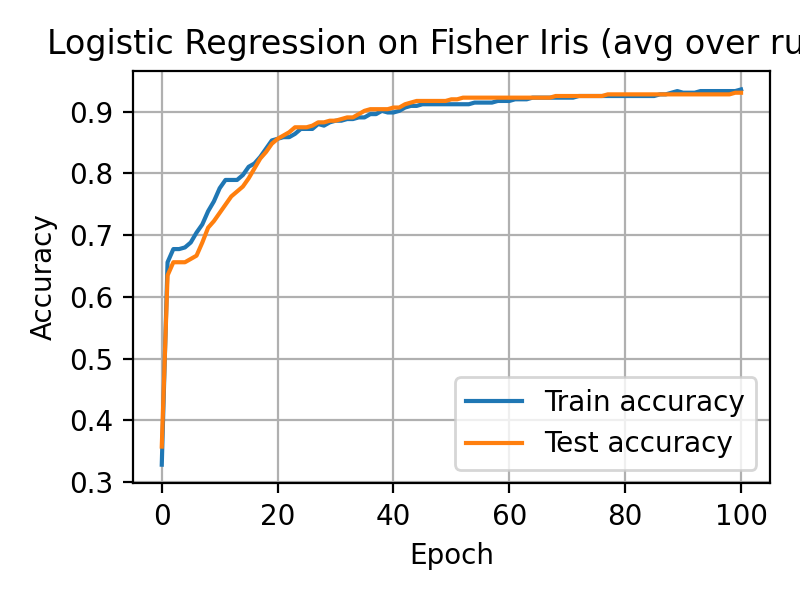


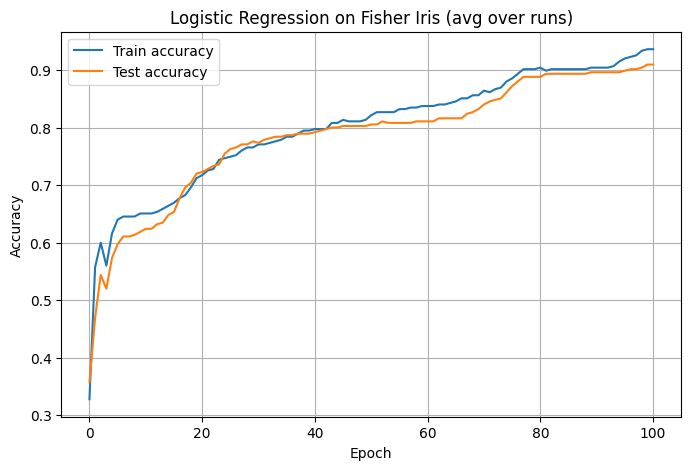

In [77]:
# ============================================================
# Question 2. Logistic Regression (5-run average)
# ============================================================

train_acc_runs_lr = np.zeros((n_runs, n_epochs + 1))
test_acc_runs_lr  = np.zeros((n_runs, n_epochs + 1))

for run in range(n_runs):
    np.random.seed(base_seed + run)

    # Shuffle each run
    ind = np.random.permutation(n_samples)
    samples_shuf = samples[ind]
    target_shuf = target[ind]

    # One-hot labels
    labels = np.zeros([n_samples, n_classes])
    for cl in range(n_classes):
        labels[target_shuf == cl, cl] = 1

    # Split 50/50
    n_train = int(n_samples / 2)
    n_test = n_samples - n_train

    train_samples = samples_shuf[:n_train]
    test_samples  = samples_shuf[-n_test:]
    train_labels  = labels[:n_train]
    test_labels   = labels[-n_test:]

    # Network size
    n_in = train_samples.shape[1]
    n_out = train_labels.shape[1]

    # Random weights (seeded): +1 for bias
    w_o = np.random.uniform(size=[n_out, n_in + 1]) * 2 - 1

    def lr_accuracy(samples_set, labels_set):
        num_correct = 0
        for sample, label in zip(samples_set, labels_set):
            # TODO: Add bias and compute LR output for sample
            x = np.concatenate(([bias], sample))
            output = sigmoid(np.dot(w_o, x))
            # TODO: prediction = argmax(output)
            prediction = np.argmax(output)  # TODO: replace with your predicted class index (an int)
            if prediction == np.argmax(label):
                num_correct += 1
        return num_correct / len(samples_set)

    # Initial accuracy
    train_acc_runs_lr[run, 0] = lr_accuracy(train_samples, train_labels)
    test_acc_runs_lr[run, 0]  = lr_accuracy(test_samples, test_labels)

    # Train (online / per-sample)
    for e in range(n_epochs):
        for sample, label in zip(train_samples, train_labels):
            # TODO: Forward pass, compute per-sample update, update weights
            x = np.concatenate(([bias], sample))
            output = sigmoid(np.dot(w_o, x))

            delta_o = (label - output) * output * (1 - output)
            w_o += lr * np.outer(delta_o, x)

        train_acc_runs_lr[run, e + 1] = lr_accuracy(train_samples, train_labels)
        test_acc_runs_lr[run, e + 1]  = lr_accuracy(test_samples, test_labels)

# TODO: Average train/test accuracy across runs and plot vs epoch.
train_acc_avg_lr = np.mean(train_acc_runs_lr, axis=0)
test_acc_avg_lr  = np.mean(test_acc_runs_lr, axis=0)

epochs = np.arange(n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_avg_lr, label='Train accuracy')
plt.plot(epochs, test_acc_avg_lr, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Logistic Regression on Fisher Iris (avg over runs)')
plt.legend()
plt.grid(True)
plt.show()



# Question 3: Extreme Learning Machine (20 pts)
Implement ELM with fixed input→hidden weights and train only output weights. Fill TODOs.

Expected plot:
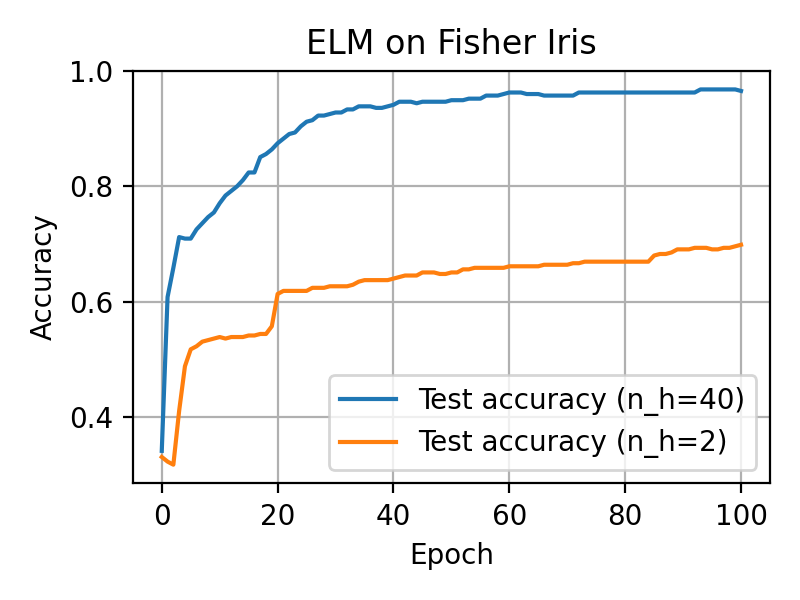


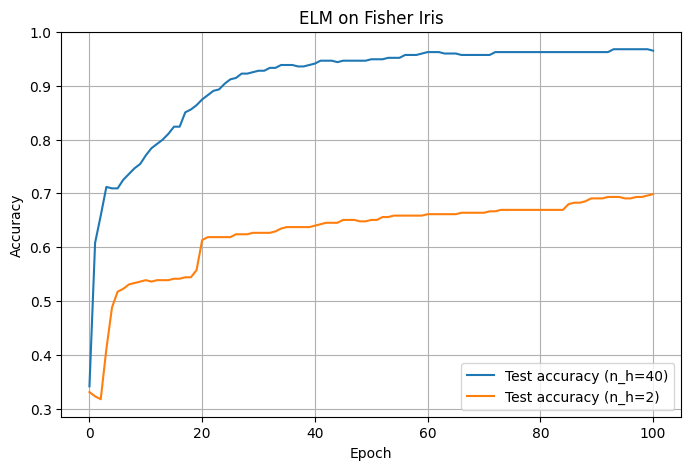

In [78]:
# ============================================================
# Question 3. Extreme Learning Machine (5-run average)
# ============================================================
def run_elm(n_h):

    train_acc_runs_elm = np.zeros((n_runs, n_epochs + 1))
    test_acc_runs_elm  = np.zeros((n_runs, n_epochs + 1))

    for run in range(n_runs):
        np.random.seed(base_seed + run)

        # Shuffle each run
        ind = np.random.permutation(n_samples)
        samples_shuf = samples[ind]
        target_shuf = target[ind]

        # One-hot labels
        labels = np.zeros([n_samples, n_classes])
        for cl in range(n_classes):
            labels[target_shuf == cl, cl] = 1

        # Split 50/50
        n_train = int(n_samples / 2)
        n_test = n_samples - n_train

        train_samples = samples_shuf[:n_train]
        test_samples  = samples_shuf[-n_test:]
        train_labels  = labels[:n_train]
        test_labels   = labels[-n_test:]

        # Network architecture
        n_in = train_samples.shape[1]

        n_out = train_labels.shape[1]

        # Initialize weights (seeded)
        w_h = np.random.uniform(size=[n_h, n_in + 1]) * 2 - 1
        w_o = np.random.uniform(size=[n_out, n_h + 1]) * 2 - 1

        def elm_accuracy(samples_set, labels_set):
            num_correct = 0
            for sample, label in zip(samples_set, labels_set):
                # TODO: Compute ELM output for sample (input→hidden→output)
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                # TODO: prediction = argmax(output)
                prediction = np.argmax(output)

                if prediction == np.argmax(label):
                    num_correct += 1
            return num_correct / len(samples_set)

        # Initial accuracy
        train_acc_runs_elm[run, 0] = elm_accuracy(train_samples, train_labels)
        test_acc_runs_elm[run, 0]  = elm_accuracy(test_samples, test_labels)

        # Train (online / per-sample) — update output weights only
        for e in range(n_epochs):
            for sample, label in zip(train_samples, train_labels):
                # Forward pass
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                # Output-layer delta rule (update only w_o)
                delta_o = (label - output)
                w_o += lr * np.outer(delta_o, h_b)

            train_acc_runs_elm[run, e + 1] = elm_accuracy(train_samples, train_labels)
            test_acc_runs_elm[run, e + 1]  = elm_accuracy(test_samples, test_labels)

    # TODO: Average train and test accuracy across runs and plot vs epoch.
    avg_train = np.mean(train_acc_runs_elm, axis=0)
    avg_test  = np.mean(test_acc_runs_elm, axis=0)

    return avg_train, avg_test

avg_train_40, avg_test_40 = run_elm(40)
# TODO: Repeat the above with n_h = 2 hidden neurons (instead of 40) and plot both cases.

avg_train_2,  avg_test_2  = run_elm(2)

epochs = np.arange(n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_test_40, label='Test accuracy (n_h=40)')
plt.plot(epochs, avg_test_2,  label='Test accuracy (n_h=2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ELM on Fisher Iris')
plt.legend()
plt.grid(True)
plt.show()



TODO: Report the final mean test accuracy for both hidden layer sizes here

## Question 3f for Graduate students: Please insert your code for question 3f in in following cell. You can add more cells if needed.

In [80]:
# -------------------------
# Code for question 3f
# -------------------------

def init_weights(shape, mode='uniform', bipolar=True, wmin=-1.0, wmax=1.0, sparsity=0.0, seed=0):
    rng = np.random.default_rng(seed)

    if mode == 'uniform':
        if bipolar:
            W = rng.uniform(wmin, wmax, size=shape)
        else:
            W = rng.uniform(0.0, wmax, size=shape)

    elif mode == 'normal':
        # choose std so values are roughly in the same scale as the uniform range
        std = (wmax - wmin) / 4.0
        mean = 0.0 if bipolar else max(0.0, (wmin + wmax) / 2.0)
        W = rng.normal(loc=mean, scale=std, size=shape)

        if not bipolar:
            W = np.abs(W)

    else:
        raise ValueError("mode must be 'uniform' or 'normal'")

    # apply sparsity: set a fraction of weights to zero before training
    if sparsity > 0.0:
        mask = rng.uniform(0.0, 1.0, size=shape) < sparsity
        W[mask] = 0.0

    return W


def run_elm_init_study(n_h, mode='uniform', bipolar=True, wmin=-1.0, wmax=1.0, sparsity=0.0):
    train_acc_runs_elm = np.zeros((n_runs, n_epochs + 1))
    test_acc_runs_elm  = np.zeros((n_runs, n_epochs + 1))

    for run in range(n_runs):
        np.random.seed(base_seed + run)

        # Shuffle each run
        ind = np.random.permutation(n_samples)
        samples_shuf = samples[ind]
        target_shuf = target[ind]

        # One-hot labels
        labels = np.zeros([n_samples, n_classes])
        for cl in range(n_classes):
            labels[target_shuf == cl, cl] = 1

        # Split 50/50
        n_train = int(n_samples / 2)
        n_test = n_samples - n_train

        train_samples = samples_shuf[:n_train]
        test_samples  = samples_shuf[-n_test:]
        train_labels  = labels[:n_train]
        test_labels   = labels[-n_test:]

        # Network architecture
        n_in = train_samples.shape[1]
        n_out = train_labels.shape[1]

        # Initialize weights for this scenario
        w_h = init_weights(
            shape=(n_h, n_in + 1),
            mode=mode,
            bipolar=bipolar,
            wmin=wmin,
            wmax=wmax,
            sparsity=sparsity,
            seed=1000 + run
        )

        w_o = np.random.uniform(size=[n_out, n_h + 1]) * 2 - 1
        def elm_accuracy(samples_set, labels_set):
            num_correct = 0
            for sample, label in zip(samples_set, labels_set):
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))
                prediction = np.argmax(output)

                if prediction == np.argmax(label):
                    num_correct += 1
            return num_correct / len(samples_set)

        # Initial accuracy
        train_acc_runs_elm[run, 0] = elm_accuracy(train_samples, train_labels)
        test_acc_runs_elm[run, 0]  = elm_accuracy(test_samples, test_labels)

        # Train output weights only
        for e in range(n_epochs):
            for sample, label in zip(train_samples, train_labels):
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                delta_o = (label - output)
                w_o += lr * np.outer(delta_o, h_b)

            train_acc_runs_elm[run, e + 1] = elm_accuracy(train_samples, train_labels)
            test_acc_runs_elm[run, e + 1]  = elm_accuracy(test_samples, test_labels)

    avg_train = np.mean(train_acc_runs_elm, axis=0)
    avg_test  = np.mean(test_acc_runs_elm, axis=0)

    return avg_train, avg_test


# ------------------------------------------------------------
# Run requested scenarios for ELM with n_h = 40
# ------------------------------------------------------------
scenarios = [
    ("Uniform, bipolar, [-1,1], 0% sparse",      'uniform', True,  -1.0,   1.0,   0.00),
    ("Normal, bipolar, [-1,1], 0% sparse",       'normal',  True,  -1.0,   1.0,   0.00),
    ("Uniform, positive, [0,1], 0% sparse",      'uniform', False,  0.0,   1.0,   0.00),
    ("Uniform, bipolar, [-1,1], 25% sparse",     'uniform', True,  -1.0,   1.0,   0.25),
    ("Uniform, bipolar, [-1,1], 50% sparse",     'uniform', True,  -1.0,   1.0,   0.50),
    ("Uniform, bipolar, [-1,1], 75% sparse",     'uniform', True,  -1.0,   1.0,   0.75),
    ("Uniform, bipolar, [-1,1], 90% sparse",     'uniform', True,  -1.0,   1.0,   0.90),
    ("Uniform, bipolar, [-0.01,0.01], 0% sparse",'uniform', True,  -0.01,  0.01,  0.00),
]

results_q3f = []

for name, mode, bipolar, wmin, wmax, sparsity in scenarios:
    avg_train, avg_test = run_elm_init_study(
        n_h=40,
        mode=mode,
        bipolar=bipolar,
        wmin=wmin,
        wmax=wmax,
        sparsity=sparsity
    )
    results_q3f.append((name, avg_train[-1], avg_test[-1]))


# ------------------------------------------------------------
# Print final accuracies in table form
# ------------------------------------------------------------
print(f"{'Scenario':50s} {'Final train acc':>16s} {'Final test acc':>16s}")
print("-" * 85)
for name, train_final, test_final in results_q3f:
    print(f"{name:50s} {train_final:16.4f} {test_final:16.4f}")

Scenario                                            Final train acc   Final test acc
-------------------------------------------------------------------------------------
Uniform, bipolar, [-1,1], 0% sparse                          0.9600           0.9627
Normal, bipolar, [-1,1], 0% sparse                           0.9547           0.9680
Uniform, positive, [0,1], 0% sparse                          0.5067           0.4800
Uniform, bipolar, [-1,1], 25% sparse                         0.9520           0.9520
Uniform, bipolar, [-1,1], 50% sparse                         0.9520           0.9627
Uniform, bipolar, [-1,1], 75% sparse                         0.9333           0.9467
Uniform, bipolar, [-1,1], 90% sparse                         0.8347           0.8400
Uniform, bipolar, [-0.01,0.01], 0% sparse                    0.5813           0.5413


# Question 4: Multi-Layer Perceptron (30 pts)
Implement MLP with backprop to update both weight matrices. Fill TODOs.

Expected plot:

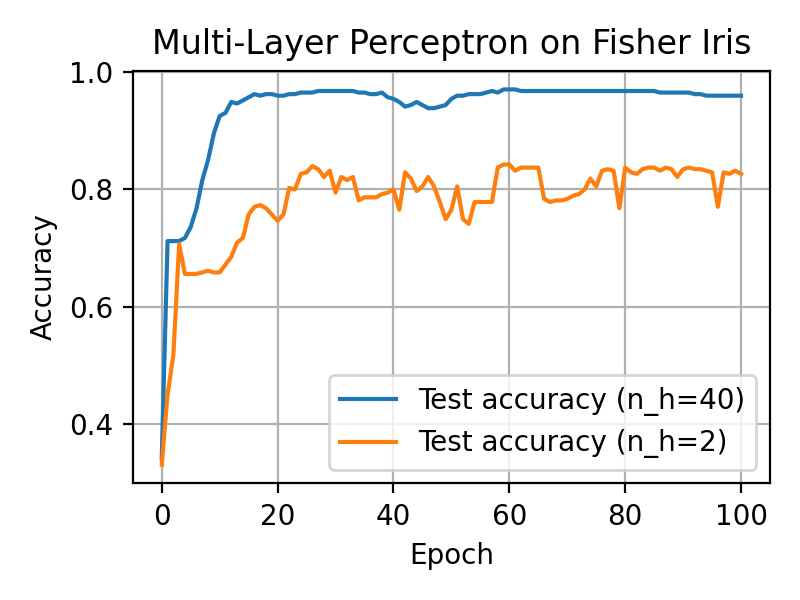


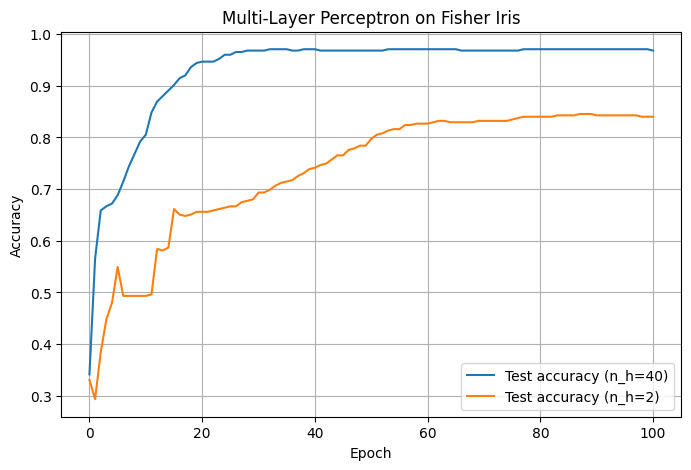

Final mean test accuracy (n_h=40): 0.968
Final mean test accuracy (n_h=2): 0.8400000000000001


In [81]:
# ============================================================
# Question 4. MLP (5-run average)
# ============================================================

def run_mlp(n_h):

    train_acc_runs_mlp = np.zeros((n_runs, n_epochs + 1))
    test_acc_runs_mlp  = np.zeros((n_runs, n_epochs + 1))

    for run in range(n_runs):
        np.random.seed(base_seed + run)

        # Shuffle each run
        ind = np.random.permutation(n_samples)
        samples_shuf = samples[ind]
        target_shuf = target[ind]

        # One-hot labels
        labels = np.zeros([n_samples, n_classes])
        for cl in range(n_classes):
            labels[target_shuf == cl, cl] = 1

        # Split 50/50
        n_train = int(n_samples / 2)
        n_test = n_samples - n_train

        train_samples = samples_shuf[:n_train]
        test_samples  = samples_shuf[-n_test:]
        train_labels  = labels[:n_train]
        test_labels   = labels[-n_test:]

        # Network architecture
        n_in = train_samples.shape[1]
        n_out = train_labels.shape[1]

        # Initialize weights (seeded)
        w_h = np.random.uniform(size=[n_h, n_in + 1]) * 2 - 1
        w_o = np.random.uniform(size=[n_out, n_h + 1]) * 2 - 1

        def mlp_accuracy(samples_set, labels_set):
            num_correct = 0
            for sample, label in zip(samples_set, labels_set):
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                prediction = np.argmax(output)
                if prediction == np.argmax(label):
                    num_correct += 1
            return num_correct / len(samples_set)

        # Initial accuracy
        train_acc_runs_mlp[run, 0] = mlp_accuracy(train_samples, train_labels)
        test_acc_runs_mlp[run, 0]  = mlp_accuracy(test_samples, test_labels)

        # Train
        for e in range(n_epochs):
            for sample, label in zip(train_samples, train_labels):
                pass
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                delta_o = (label - output) * output * (1 - output)

                delta_h = h * (1 - h) * np.dot(w_o[:, 1:].T, delta_o)

                w_o += lr * np.outer(delta_o, h_b)

                delta_h = h * (1 - h) * np.dot(w_o[:, 1:].T, delta_o)
                w_h += lr * np.outer(delta_h, x)

            train_acc_runs_mlp[run, e + 1] = mlp_accuracy(train_samples, train_labels)
            test_acc_runs_mlp[run, e + 1]  = mlp_accuracy(test_samples, test_labels)

    avg_train = np.mean(train_acc_runs_mlp, axis=0)
    avg_test  = np.mean(test_acc_runs_mlp, axis=0)

    return avg_train, avg_test


# Run experiments
avg_train_40, avg_test_40 = run_mlp(40)
avg_train_2,  avg_test_2  = run_mlp(2)

epochs = np.arange(n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_test_40, label='Test accuracy (n_h=40)')
plt.plot(epochs, avg_test_2,  label='Test accuracy (n_h=2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Multi-Layer Perceptron on Fisher Iris')
plt.legend()
plt.grid(True)
plt.show()

print("Final mean test accuracy (n_h=40):", avg_test_40[-1])
print("Final mean test accuracy (n_h=2):",  avg_test_2[-1])


## Question 4f for Graduate students: Please insert your code for question 4f in in following cell. You can add more cells if needed.

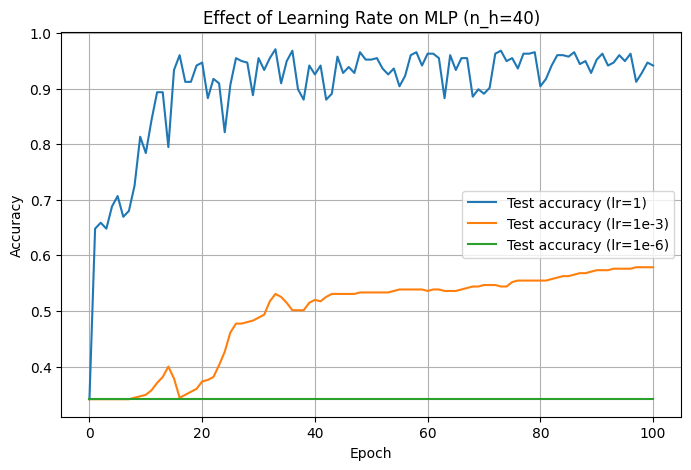

Final test accuracy (lr=1): 0.9413333333333334
Final test accuracy (lr=1e-3): 0.5786666666666667
Final test accuracy (lr=1e-6): 0.3413333333333333


In [82]:
# -------------------------
# Code for question 4f
# -------------------------

def run_mlp(n_h, lr_val):
    train_acc_runs_mlp = np.zeros((n_runs, n_epochs + 1))
    test_acc_runs_mlp  = np.zeros((n_runs, n_epochs + 1))

    for run in range(n_runs):
        np.random.seed(base_seed + run)

        # Shuffle each run
        ind = np.random.permutation(n_samples)
        samples_shuf = samples[ind]
        target_shuf = target[ind]

        # One-hot labels
        labels = np.zeros([n_samples, n_classes])
        for cl in range(n_classes):
            labels[target_shuf == cl, cl] = 1

        # Split 50/50
        n_train = int(n_samples / 2)
        n_test = n_samples - n_train

        train_samples = samples_shuf[:n_train]
        test_samples  = samples_shuf[-n_test:]
        train_labels  = labels[:n_train]
        test_labels   = labels[-n_test:]

        # Network architecture
        n_in = train_samples.shape[1]
        n_out = train_labels.shape[1]

        # Initialize weights
        w_h = np.random.uniform(size=[n_h, n_in + 1]) * 2 - 1
        w_o = np.random.uniform(size=[n_out, n_h + 1]) * 2 - 1

        def mlp_accuracy(samples_set, labels_set):
            num_correct = 0
            for sample, label in zip(samples_set, labels_set):
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))
                prediction = np.argmax(output)

                if prediction == np.argmax(label):
                    num_correct += 1
            return num_correct / len(samples_set)

        # Initial accuracy
        train_acc_runs_mlp[run, 0] = mlp_accuracy(train_samples, train_labels)
        test_acc_runs_mlp[run, 0]  = mlp_accuracy(test_samples, test_labels)

        # Train
        for e in range(n_epochs):
            for sample, label in zip(train_samples, train_labels):
                x = np.concatenate(([bias], sample))
                h = sigmoid(np.dot(w_h, x))
                h_b = np.concatenate(([bias], h))
                output = sigmoid(np.dot(w_o, h_b))

                delta_o = (label - output) * output * (1 - output)
                delta_h = h * (1 - h) * np.dot(w_o[:, 1:].T, delta_o)

                w_o += lr_val * np.outer(delta_o, h_b)
                w_h += lr_val * np.outer(delta_h, x)

            train_acc_runs_mlp[run, e + 1] = mlp_accuracy(train_samples, train_labels)
            test_acc_runs_mlp[run, e + 1]  = mlp_accuracy(test_samples, test_labels)

    avg_train = np.mean(train_acc_runs_mlp, axis=0)
    avg_test  = np.mean(test_acc_runs_mlp, axis=0)

    return avg_train, avg_test


# Run the experiment for 3 learning rates
avg_train_lr1,   avg_test_lr1   = run_mlp(40, 1)
avg_train_lr1e3, avg_test_lr1e3 = run_mlp(40, 1e-3)
avg_train_lr1e6, avg_test_lr1e6 = run_mlp(40, 1e-6)

# Plot all three test curves
epochs = np.arange(n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_test_lr1,   label='Test accuracy (lr=1)')
plt.plot(epochs, avg_test_lr1e3, label='Test accuracy (lr=1e-3)')
plt.plot(epochs, avg_test_lr1e6, label='Test accuracy (lr=1e-6)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate on MLP (n_h=40)')
plt.legend()
plt.grid(True)
plt.show()

print("Final test accuracy (lr=1):", avg_test_lr1[-1])
print("Final test accuracy (lr=1e-3):", avg_test_lr1e3[-1])
print("Final test accuracy (lr=1e-6):", avg_test_lr1e6[-1])

# Graduate students: 4f descriptive question: Describe how learning rate affects the MLP network's accuracy and explain why.

YOUR ANSWER HERE:For a large learning rate(lr=1), the network exhibits unstable behavior.The accuracy fluctuates and may not converge. For very small learning rate the network learens very slowly. The accuracy improvement is not much because the weight updates are too small to make meaningful progress.For moderate learning rate, the network achieves the best performance. The accuracy increases smoothly and converges to a high value. It provides a good balance between convergence speed and stability.

TODO: Report the final mean test accuracy for both hidden layer sizes here

# Extra Credit Question 5 — Trace-based STDP + Synaptic Scaling

You will simulate 25 Poisson input spike trains connected to a single LIF neuron.
The goal is to learn weights that resemble the 5×5 input pattern.

**Given (from PDF):**
- Simulation timestep: $\Delta T = 1$ ms
- Total duration: $T = 350$ ms
- Max firing rate: $r_{max}=75$ Hz with $r_i = I_i\,r_{max}$
- Trace decay: $k=0.95$
- Learning rate: $A=0.05$ (step size in trace rule)
- Target trace: $X_{tar}=0.15$
- Synaptic scaling: $\alpha=1.0$ with $w_i \leftarrow \frac{w_i}{\sum_j w_j}\,\alpha$
- Weight bounds: $w_{min}, w_{max} = -1, 1$

Use the helper functions below and fill in TODOs.


- **Bounded weights:** After each update step (including scaling), ensure all weights remain within $[w_{min}, w_{max}]$ (e.g., using clipping).

In [83]:
## This is a helper function

def lif_step(V_t, I_t, Rm, Cm, Vrest, Vth, dt):
    """One-step LIF update; spike check at V_{t+1}; spike -> reset to Vrest."""
    Tm = Rm * Cm
    V_next = V_t + (dt / Tm) * (-(V_t - Vrest) + Rm * I_t)

    spk = 0
    if V_next >= Vth:
        spk = 1
        V_next = Vrest

    return V_next, spk


## Extra Credit Question 5(a)

In [84]:
def generate_poisson_spikes(rates_hz, T_s, dt, seed=7):
    """
    Homogeneous Poisson spikes using:
      x ~ Uniform(0,1), spike if x < r*dt
    where dt is in seconds.

    Inputs:
      rates_hz : shape (N,) firing rates in Hz
      T_s      : total duration in seconds
      dt       : timestep in seconds
      seed     : random seed for reproducibility

    Output:
      spikes : shape (n_steps, N) with values 0/1
    """

    # Hint (use this exact RNG line for reproducibility):
    rng = np.random.default_rng(seed)

    # TODO:
    # - Convert rates_hz into a NumPy array (float).
    rates_hz = np.array(rates_hz, dtype=float)
    # - Determine the number of simulation time steps.
    N = len(rates_hz)
    n_steps = int(np.round(T_s / dt))
    # - Compute the spike probability per time step for each neuron: p_i = r_i * dt.
    p = rates_hz * dt
    # - Draw uniform random numbers x in [0,1] for every (time step, neuron) using:
    x = rng.uniform(0.0, 1.0, size=(n_steps, N))
    # - Emit a spike (1) when x < p_i, otherwise 0.
    spikes = (x < p).astype(int)
    # - Return a (n_steps, N) spike matrix with values 0/1.
    return spikes





In [26]:
# -------------------------
# ASSERTS for poisson spike generation (do not modify)
# -------------------------
_rates_test = np.array([0.0, 10.0, 50.0], dtype=float)  # Hz
_T_s_test = 0.01   # 10 ms
_dt_test  = 0.001  # 1 ms
_seed_test = 7

_sp = generate_poisson_spikes(_rates_test, _T_s_test, _dt_test, seed=_seed_test)

# shape
assert _sp.shape == (int(np.round(_T_s_test / _dt_test)), _rates_test.size), "Wrong output shape"
# binary
assert np.all((_sp == 0) | (_sp == 1)), "Spikes must be binary (0/1)"

# exact reference behavior for the provided procedure + seed
_rng_ref = np.random.default_rng(_seed_test)
_n_steps_ref = int(np.round(_T_s_test / _dt_test))
_p_ref = np.clip(_rates_test * _dt_test, 0.0, 1.0)
_x_ref = _rng_ref.uniform(0.0, 1.0, size=(_n_steps_ref, _rates_test.size))
_sp_ref = (_x_ref < _p_ref.reshape(1, -1)).astype(int)
assert np.array_equal(_sp, _sp_ref), "Poisson sampling rule / seed handling is incorrect"

## Extra Credit Question 5(b)–(d): Clean image experiment
Fill TODOs to run the learning simulation and plot the learned weights as a 5×5 image.

Expected plot:

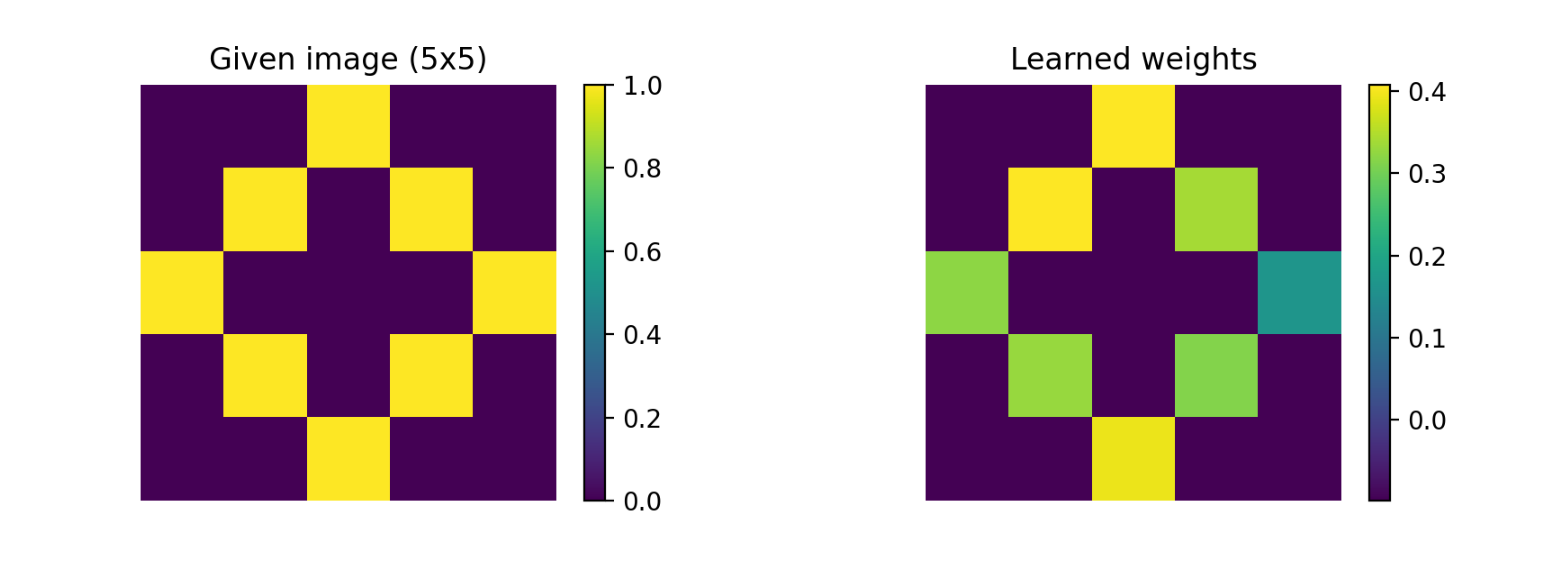


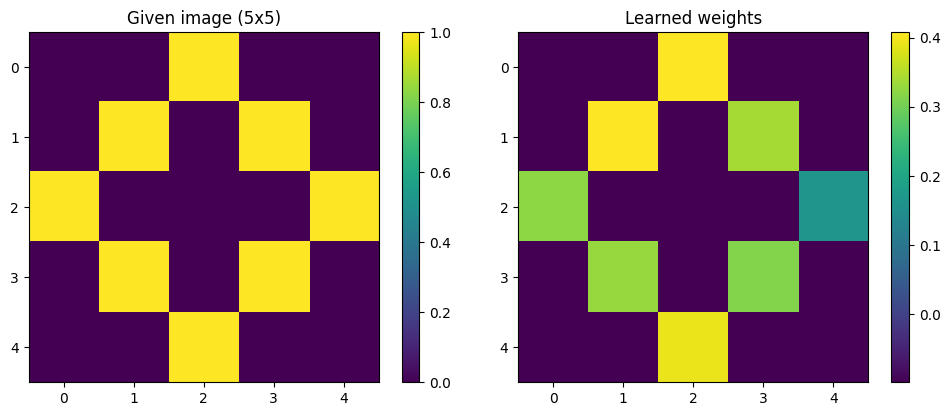

In [85]:
# ============================================================
# Extra Credit: Clean image experiment
# ============================================================

# Given image (normalized pixel intensities)
img = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=float)

w_min = -1
w_max = 1

# Single timestep (seconds): 1 ms
dt = 0.001  # s

# Total simulation time: 350 ms = 0.350 s
T_s = 0.350
n_steps = int(np.round(T_s / dt))

# Convert image -> firing rates (Hz)
max_rate_hz = 75.0
rates_hz = max_rate_hz * img.reshape(-1)  # (25,)

# Generate 25 Poisson spike trains: spikes_in[t, i]
spikes_in = generate_poisson_spikes(rates_hz, T_s=T_s, dt=dt, seed=7)

# Trace rule parameters
k = 0.95
A = 0.05
X_tar = 0.15

# Synaptic scaling: normalize so sum(w)=alpha_scale
alpha_scale = 1.0

# Weight initialization
rng_w = np.random.default_rng(7)
w = rng_w.uniform(0.0, 0.1, size=rates_hz.size)  # (25,)

# LIF parameters (from PDF Table)
Rm = 100e6
Cm = 100e-12
Vrest = -0.065
Vth = -0.025

# Initialize trace variable and membrane potential
X_pre = np.zeros_like(w)
v = Vrest



for t in range(n_steps):
    s_pre = spikes_in[t]  # shape (25,)

    # TODO: Update pre-trace:
    #   1) decay all traces:
    X_pre = k * X_pre
    #   2) set-to-1 where there is an input spike:
    X_pre[s_pre==1] = 1


    # TODO: Compute injected current I(t) as a dot product of weights and spikes
    I_t = np.dot(w, s_pre)

    # TODO: Determine the membrane potential and spiking activity of LIF update using lif_step(...)
    v, s_post = lif_step(v, I_t, Rm, Cm, Vrest, Vth, dt)
    # TODO: If post spikes, update weights using trace rule and apply synaptic scaling. Clip the weights to w_min and w_max.
    if s_post == 1:
        w = w + A * (X_pre - X_tar)

        # Synaptic scaling
        w_sum = np.sum(w)
        if w_sum != 0:
            w = (w / w_sum) * alpha_scale

        # Clip to bounds
        w = np.clip(w, w_min, w_max)


# TODO: Plot learned weights as 5x5 image
w_img = w.reshape(5, 5)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='viridis')
plt.title('Given image (5x5)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(w_img, cmap='viridis')
plt.title('Learned weights')
plt.colorbar()

plt.tight_layout()
plt.show()



## Extra Credit (Noisy image experiment)
Add independent uniform noise to every pixel: $N_{ij} \sim U(0,0.2)$, then
\[
I_{noisy} = \mathrm{clip}(I + N, 0, 1)
\]
Repeat the full simulation using $I_{noisy}$, using the τ that gave best results in the clean-image experiment.

### (f) Noisy image, **no scaling**
Repeat parts (a)–(d) for the noisy image **without synaptic scaling**.


- (Noisy image, no scaling) Repeat the simulation without synaptic scaling and plot learned weights.
- (Noisy image, with scaling) Repeat the simulation with synaptic scaling and plot learned weights.

Expected plot:

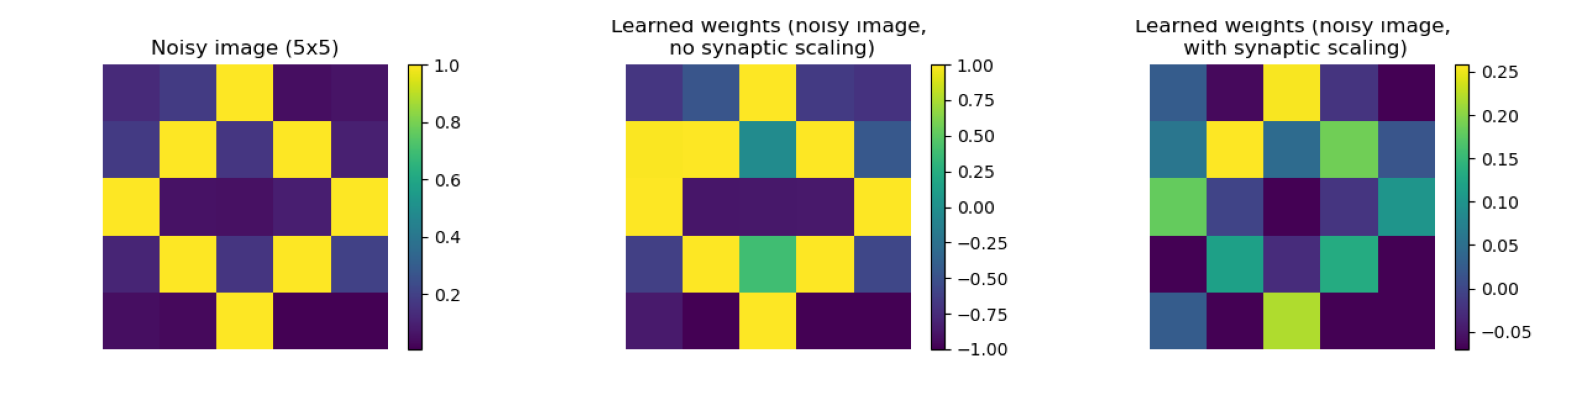

### Question 5e

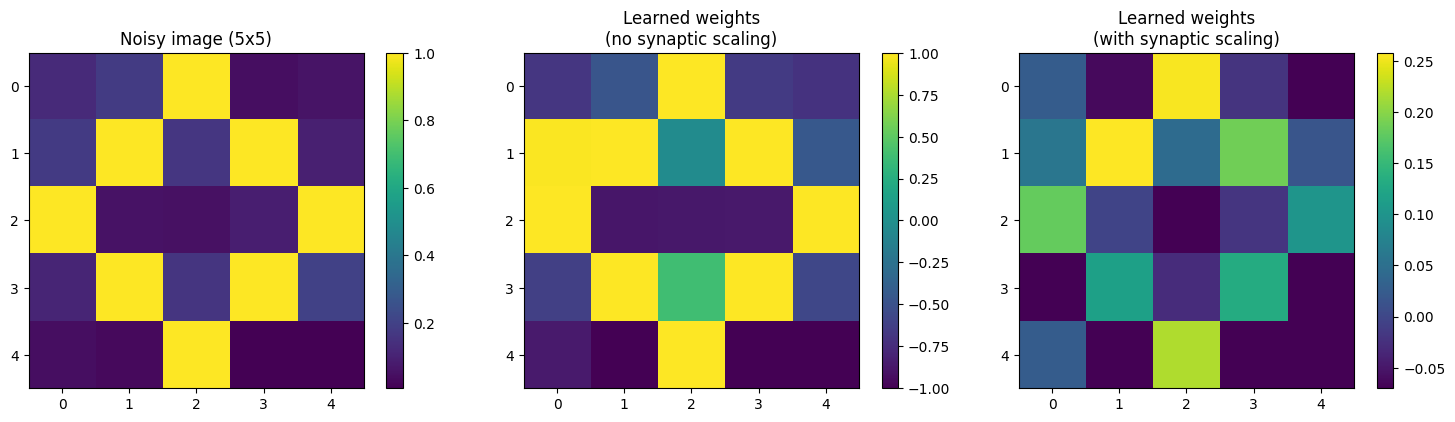

In [86]:
# ============================================================
# Question 5e: Noisy image experiments
# ============================================================

# Given image (normalized pixel intensities)
img = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=float)

# Single timestep (seconds): 1 ms
dt = 0.001  # s

# Total simulation time: 350 ms = 0.350 s
T_s = 0.350
n_steps = int(np.round(T_s / dt))

# --- Generate noisy image ---
rng = np.random.default_rng(7)

noise_low = 0.0
noise_high = 0.2
noise = rng.uniform(noise_low, noise_high, size=img.shape)

# Add noise and clip to [0,1]
img_noisy = np.clip(img + noise, 0.0, 1.0)

# Convert image -> firing rates (Hz)
max_rate_hz = 100.0
rates_hz = max_rate_hz * img_noisy.reshape(-1)  # (25,)

# Generate 25 Poisson spike trains: spikes_in[t, i]
spikes_in = generate_poisson_spikes(rates_hz, T_s=T_s, dt=dt, seed=7)

# Trace rule parameters
k = 0.9
A = 0.05
X_tar = 0.15

# Synaptic scaling: normalize so sum(w)=alpha_scale
alpha_scale = 1.0

# Weight initialization
rng_w = np.random.default_rng(7)
w_init = rng_w.uniform(0.0, 0.1, size=rates_hz.size)  # (25,)

# LIF parameters
Rm = 100e6
Cm = 100e-12
Vrest = -0.065
Vth = -0.025

w = w_init.copy()
X_pre = np.zeros_like(w)
v = Vrest

for t in range(n_steps):
    s_pre = spikes_in[t]

    X_pre = k * X_pre
    X_pre[s_pre == 1] = 1

    I_t = np.dot(w, s_pre)
    v, s_post = lif_step(v, I_t, Rm, Cm, Vrest, Vth, dt)

    if s_post == 1:
        w = w + A * (X_pre - X_tar)
        w = np.clip(w, -1, 1)

w_no_scale = w.copy()

# ---------- (f) Noisy image, with synaptic scaling ----------
w = w_init.copy()
X_pre = np.zeros_like(w)
v = Vrest

for t in range(n_steps):
    s_pre = spikes_in[t]  # shape (25,)
  # TODO: Repeat the steps outlined for the clean image  with img_noisy and apply synaptic scaling
    X_pre = k * X_pre
    X_pre[s_pre == 1] = 1
    I_t = np.dot(w, s_pre)
    v, s_post = lif_step(v, I_t, Rm, Cm, Vrest, Vth, dt)

    if s_post == 1:
        w = w + A * (X_pre - X_tar)
        w_sum = np.sum(w)
        if w_sum != 0:
            w = (w / w_sum) * alpha_scale
        w = np.clip(w, -1, 1)
w_scale = w.copy()

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_noisy, cmap='viridis')
plt.title('Noisy image (5x5)')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(w_no_scale.reshape(5, 5), cmap='viridis')
plt.title('Learned weights\n(no synaptic scaling)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(w_scale.reshape(5, 5), cmap='viridis')
plt.title('Learned weights\n(with synaptic scaling)')
plt.colorbar()

plt.tight_layout()
plt.show()


## Extra Credit Question 5f

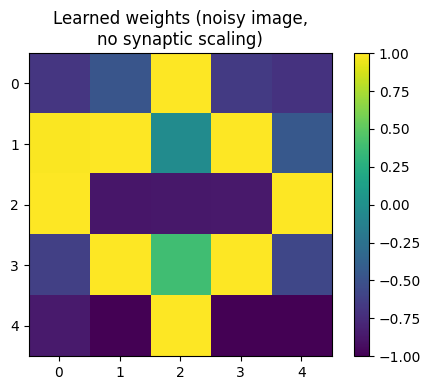

In [87]:
# TODO: Repeat the experiment in 5e but do not apply synaptic scaling to weights
# TODO: Repeat the experiment in 5e but do not apply synaptic scaling to weights

w = w_init.copy()
X_pre = np.zeros_like(w)
v = Vrest

for t in range(n_steps):
    s_pre = spikes_in[t]  # shape (25,)

    # Update pre-trace
    X_pre = k * X_pre
    X_pre[s_pre == 1] = 1

    # Compute injected current
    I_t = np.dot(w, s_pre)

    # LIF update
    v, s_post = lif_step(v, I_t, Rm, Cm, Vrest, Vth, dt)

    # If post spikes, update weights WITHOUT synaptic scaling
    if s_post == 1:
        w = w + A * (X_pre - X_tar)
        w = np.clip(w, -1, 1)

w_no_scale = w.copy()

plt.figure(figsize=(5, 4))
plt.imshow(w_no_scale.reshape(5, 5), cmap='viridis')
plt.title('Learned weights (noisy image,\nno synaptic scaling)')
plt.colorbar()
plt.tight_layout()
plt.show()

### (g) True/False
Synaptic scaling does *not* prevent synaptic weights from saturating at their bounds; it only affects the neuron's firing rate.

**Answer:** False